# OmniPath Ground Truth Collection
Build a **TF → target gene** regulatory ground truth from OmniPath's *transcriptional* layer for the protein/gene embedding benchmark.

Unlike CORUM / STRING / KEGG / Reactome / GO CC (protein–protein associations), this matrix captures **gene-regulatory** relationships: a transcription factor and the gene it regulates. This is the same OmniPath layer used as ground truth in the **scPRINT** paper (TF–gene pairs).

**Source dataset:** `omnipath.interactions.Transcriptional` (organism = human), which aggregates DoRothEA and other curated TF–target resources.

**Choices for this build:**
- **All edges** in the transcriptional layer are positives (no confidence / `n_references` filter).
- TF **complexes** (`source = COMPLEX:Pxxxxx_Qyyyyy`) are expanded so that *each member* TF → target becomes an edge.
- Edges are **symmetrised** (undirected) to match the symmetric structure of the other ground-truth matrices.

Same matrix structure as the other notebooks: `1` positive, `0` negative, `NaN` = at least one protein outside the OmniPath transcriptional network. Proteins are ordered using the **shared** `ground_truth_proteins.tsv` index so this matrix aligns row-for-row with CORUM / STRING / KEGG / Reactome / GO CC.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from matplotlib.patches import Patch
from omnipath.interactions import Transcriptional

## 0. Locate the shared ground-truth folder

The canonical protein universe lives in `protgpt/ppi_ground_truth/ground_truth_proteins.tsv` (20,431 alphabetically-sorted UniProt accessions, derived from the human canonical proteome FASTA). All shipped matrices are `(20431, 20431)`, so we key off this file to guarantee alignment.

In [2]:
from omicsfm.attention import GT_DIR_DEFAULT, save_ppi_ground_truth
from pathlib import Path

# reference/ holds the matrices; GT_DIR_DEFAULT resolves it wherever
# omicsfm is installed, so this does not depend on the working directory.
GT_DIR = Path(GT_DIR_DEFAULT)

REPO = GT_DIR.parent
PROT_TSV = GT_DIR / 'ground_truth_proteins.tsv'
print('repo root :', REPO)
print('gt dir    :', GT_DIR)
print('proteins  :', PROT_TSV.exists())

repo root : C:\Users\sander\OneDrive\Bureaublad\Projects\prot_GPT\code\protgpt
gt dir    : C:\Users\sander\OneDrive\Bureaublad\Projects\prot_GPT\code\protgpt\protgpt\ppi_ground_truth
proteins  : True


# 1. Fetch the OmniPath transcriptional (TF→target) interactions

The `omnipath` package queries the OmniPath web service and caches the result locally (`~/.cache/omnipath` / pypath cache). Columns of interest are `source` (the TF, possibly a `COMPLEX:` of UniProt ACs) and `target` (the regulated gene, a UniProt AC).

In [3]:
df_tf = Transcriptional.get(organism='human')

print(f"Total TF→target interactions: {len(df_tf):,}")
print(f"Columns: {list(df_tf.columns)}")
df_tf[['source', 'target', 'is_stimulation', 'is_inhibition', 'n_references']].head(8)

Total TF→target interactions: 131,398
Columns: ['source', 'target', 'is_directed', 'is_stimulation', 'is_inhibition', 'consensus_direction', 'consensus_stimulation', 'consensus_inhibition', 'sources', 'references', 'curation_effort', 'n_sources', 'n_primary_sources', 'n_references', 'references_stripped']


,source,target,is_stimulation,is_inhibition,n_references
0,P01106,O14746,True,False,74
1,COMPLEX:P19838_Q04864,P10145,True,False,234
2,P17947,P02818,True,False,1
3,COMPLEX:P05412_P17535,P05412,True,False,49
4,COMPLEX:P01100_P17535,P05412,True,False,49
5,COMPLEX:P17275,P05412,True,False,49
6,COMPLEX:P05412_P17275,P05412,True,False,49
7,COMPLEX:Q00653,P10145,True,False,234


In [4]:
# The source can be a single TF or a TF complex (COMPLEX:Pxxxxx_Qyyyyy);
# targets are (almost always) single UniProt accessions.
n_complex_src = df_tf['source'].str.startswith('COMPLEX:').sum()
n_complex_tgt = df_tf['target'].str.startswith('COMPLEX:').sum()
print(f"Rows with a COMPLEX source: {n_complex_src:,} ({n_complex_src/len(df_tf)*100:.1f}%)")
print(f"Rows with a COMPLEX target: {n_complex_tgt:,}")
print(f"Unique sources: {df_tf['source'].nunique():,}  |  unique targets: {df_tf['target'].nunique():,}")
print("\nExample complex source:", df_tf.loc[df_tf['source'].str.startswith('COMPLEX:'), 'source'].iloc[0])

Rows with a COMPLEX source: 22,993 (17.5%)
Rows with a COMPLEX target: 11
Unique sources: 1,483  |  unique targets: 15,739

Example complex source: COMPLEX:P19838_Q04864


# 2. Expand TF complexes and build undirected TF–target pairs

For each interaction we expand any `COMPLEX:` endpoint into its member UniProt accessions, then emit an undirected pair `(min, max)` for every (source-member, target-member) combination. Self-pairs are dropped.

In [5]:
def members(node: str) -> list[str]:
    """COMPLEX:P19838_Q04864 -> [P19838, Q04864]; single AC -> [AC]."""
    if node.startswith('COMPLEX:'):
        return [m for m in node[len('COMPLEX:'):].split('_') if m]
    return [node]

positive_pairs = set()
omnipath_nodes = set()

for src, tgt in zip(df_tf['source'], df_tf['target']):
    src_members = members(src)
    tgt_members = members(tgt)
    for a in src_members:
        omnipath_nodes.add(a)
        for b in tgt_members:
            omnipath_nodes.add(b)
            if a != b:
                positive_pairs.add(tuple(sorted((a, b))))

print(f"Unique TF/target proteins (nodes): {len(omnipath_nodes):,}")
print(f"Undirected positive pairs:         {len(positive_pairs):,}")

Unique TF/target proteins (nodes): 15,790
Undirected positive pairs:         113,742


# 3. Load the canonical protein universe

Proteins ordered alphabetically — identical order and content to the CORUM / STRING / KEGG / Reactome / GO CC matrices.

In [6]:
prot_df = pd.read_csv(PROT_TSV, sep='\t')
all_proteins_sorted = prot_df['protein'].tolist()
n = len(all_proteins_sorted)
prot_to_idx = {p: i for i, p in enumerate(all_proteins_sorted)}
assert all_proteins_sorted == sorted(all_proteins_sorted), 'universe must be alphabetical'

print(f"Total proteins: {n}")
print(f"Matrix shape: {n} x {n}")

Total proteins: 20431
Matrix shape: 20431 x 20431


In [7]:
universe = set(all_proteins_sorted)
in_both = omnipath_nodes & universe
op_only = omnipath_nodes - universe

print(f"OmniPath transcriptional proteins: {len(omnipath_nodes):,}")
print(f"In both OmniPath and universe:     {len(in_both):,}")
print(f"In OmniPath only (not in universe):{len(op_only):,}")
if op_only:
    print(f"\nSample OmniPath-only IDs: {sorted(op_only)[:10]}")

OmniPath transcriptional proteins: 15,790
In both OmniPath and universe:     15,786
In OmniPath only (not in universe):4

Sample OmniPath-only IDs: ['O60361', 'P01562', 'Q3SXR2', 'Q5SWW7']


# 4. Build the ground truth matrix

- `1` = positive (TF–target edge, both proteins in the universe)
- `0` = negative (both proteins in the OmniPath transcriptional network, no edge)
- `NaN` = at least one protein not in the OmniPath transcriptional network

"In the network" = the protein appears as a TF or a target in at least one transcriptional interaction.

In [8]:
# Initialize all NaN
omnipath_matrix = np.full((n, n), np.nan, dtype=np.float32)

# Filter OmniPath nodes to the universe; set all OmniPath×OmniPath pairs to 0 (negative by default)
op_in_universe = sorted(p for p in omnipath_nodes if p in prot_to_idx)
op_indices = np.array([prot_to_idx[p] for p in op_in_universe])

omnipath_matrix[np.ix_(op_indices, op_indices)] = 0.0
print(f"OmniPath proteins in universe: {len(op_indices)} / {n}")
print(f"Set {len(op_indices)}x{len(op_indices)} OmniPath submatrix to 0 (negative)")

OmniPath proteins in universe: 15786 / 20431
Set 15786x15786 OmniPath submatrix to 0 (negative)


In [9]:
# Set positives from the TF–target pairs
n_set = 0
n_skipped = 0
for p1, p2 in positive_pairs:
    if p1 in prot_to_idx and p2 in prot_to_idx:
        i, j = prot_to_idx[p1], prot_to_idx[p2]
        omnipath_matrix[i, j] = 1.0
        omnipath_matrix[j, i] = 1.0
        n_set += 1
    else:
        n_skipped += 1

print(f"Set {n_set:,} positive pairs (both directions)")
print(f"Skipped {n_skipped:,} pairs (protein not in universe)")

Set 113,686 positive pairs (both directions)
Skipped 56 pairs (protein not in universe)


In [10]:
# Set diagonal to NaN
np.fill_diagonal(omnipath_matrix, np.nan)

# Verify counts
upper = omnipath_matrix[np.triu_indices(n, k=1)]
n_pos = np.nansum(upper == 1)
n_neg = np.nansum(upper == 0)
n_nan = np.sum(np.isnan(upper))

print(f"Upper triangle counts:")
print(f"  Positive (1): {int(n_pos):>12,}")
print(f"  Negative (0): {int(n_neg):>12,}")
print(f"  NaN:          {int(n_nan):>12,}")
print(f"  Total:        {len(upper):>12,}")
print(f"\n  Pos/Neg ratio: {n_pos/n_neg:.6f}")
print(f"  Matrix is symmetric: {np.allclose(omnipath_matrix, omnipath_matrix.T, equal_nan=True)}")

Upper triangle counts:
  Positive (1):      113,686
  Negative (0):  124,477,319
  NaN:            84,111,660
  Total:         208,702,665

  Pos/Neg ratio: 0.000913


  Matrix is symmetric: True


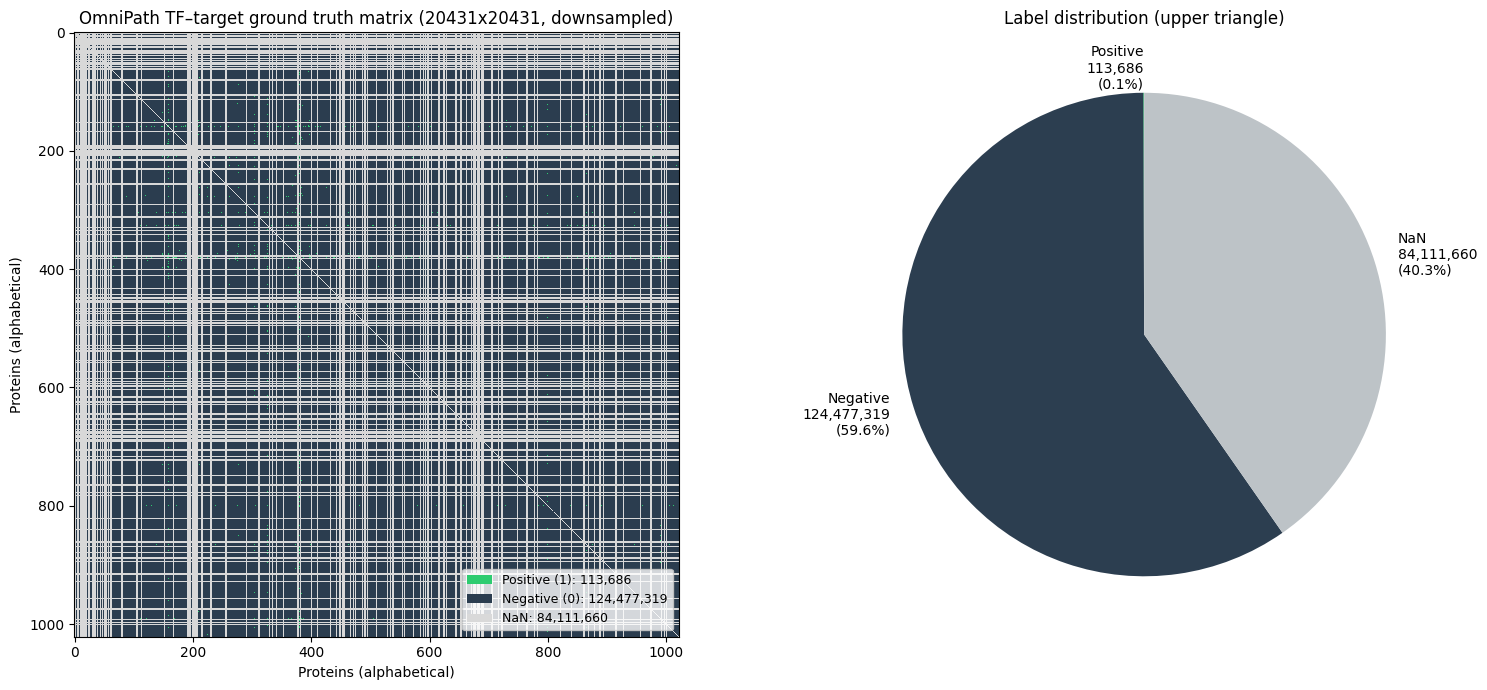

In [11]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

step = max(1, n // 1000)
display_matrix = omnipath_matrix[::step, ::step]

rgb = np.zeros((*display_matrix.shape, 3), dtype=np.float32)
nan_mask = np.isnan(display_matrix)
neg_mask = display_matrix == 0
pos_mask = display_matrix == 1

rgb[nan_mask] = [0.85, 0.85, 0.85]
rgb[neg_mask] = [0.17, 0.24, 0.31]
rgb[pos_mask] = [0.18, 0.80, 0.44]

axes[0].imshow(rgb, aspect='equal', interpolation='nearest')
axes[0].set_title(f"OmniPath TF–target ground truth matrix ({n}x{n}, downsampled)", fontsize=12)
axes[0].set_xlabel("Proteins (alphabetical)")
axes[0].set_ylabel("Proteins (alphabetical)")

legend_elements = [
    Patch(facecolor=[0.18, 0.80, 0.44], label=f'Positive (1): {int(n_pos):,}'),
    Patch(facecolor=[0.17, 0.24, 0.31], label=f'Negative (0): {int(n_neg):,}'),
    Patch(facecolor=[0.85, 0.85, 0.85], label=f'NaN: {int(n_nan):,}'),
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=9)

sizes_plot = [int(n_pos), int(n_neg), int(n_nan)]
labels = [f'Positive\n{int(n_pos):,}\n({n_pos/len(upper)*100:.1f}%)',
          f'Negative\n{int(n_neg):,}\n({n_neg/len(upper)*100:.1f}%)',
          f'NaN\n{int(n_nan):,}\n({n_nan/len(upper)*100:.1f}%)']
colors = ['#2ecc71', '#2c3e50', '#bdc3c7']

axes[1].pie(sizes_plot, labels=labels, colors=colors, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Label distribution (upper triangle)', fontsize=12)

plt.tight_layout()
plt.show()

In [12]:
from pathlib import Path
from omicsfm.attention import GT_DIR_DEFAULT, save_ppi_ground_truth

# save_ppi_ground_truth stores only the positives and the covered-protein
# universe (~36x smaller, reconstructs the dense matrix exactly) and will
# not replace an existing file: published results are pinned to the
# matrices in reference/, and these source databases change over time.
# save
out_npz = GT_DIR / 'omnipath_ground_truth_matrix.npz'

save_ppi_ground_truth(Path(GT_DIR_DEFAULT) / "omnipath_ground_truth_matrix.npz", omnipath_matrix)

npz_size = out_npz.stat().st_size / 1e6
print(f"Saved {out_npz.name} ({npz_size:.1f} MB)")
print(f"\nParameters used:")
print(f"  Source: omnipath.interactions.Transcriptional (organism=human)")
print(f"  Layer: TF→target gene regulation (scPRINT-style)")
print(f"  Confidence filter: none (all edges)")
print(f"  TF complexes: expanded to member UniProt ACs")
print(f"  Symmetrised: yes")
print(f"\nTo load later:")
print(f"  matrix = np.load('omnipath_ground_truth_matrix.npz')['matrix']")
print(f"  # shape ({n}, {n}), values: 0, 1, NaN")

Saved omnipath_ground_truth_matrix.npz (58.8 MB)
Saved omnipath_ground_truth_proteins.tsv

Parameters used:
  Source: omnipath.interactions.Transcriptional (organism=human)
  Layer: TF→target gene regulation (scPRINT-style)
  Confidence filter: none (all edges)
  TF complexes: expanded to member UniProt ACs
  Symmetrised: yes

To load later:
  matrix = np.load('omnipath_ground_truth_matrix.npz')['matrix']
  # shape (20431, 20431), values: 0, 1, NaN
